In [4]:
import sys
sys.path.append('../src')
import os
print(os.path.abspath('../src'))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_preprocessing import load_data, split_data, get_feature_names

# Load trained model 
pipeline = joblib.load('../models/linear_regression_best.pkl')

# Reload the dataset to obtain X_test and y_test for evaluation
df = load_data('../data/house_prices_clean.csv')
X_train, X_test, y_train, y_test = split_data(df)

d:\File Code\house-price-prediction\src
Grouped 148 rare addresses (< 20 samples) into 'Other'
Number of remaining unique addresses: 45


In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 0.2621
RMSE : 0.3998
R2   : 0.8637


## Overall Evaluation

The model achieved an **R² score of approximately 0.86** on the test set, indicating that the selected features (property area, number of rooms, amenities, and location) explain about **86% of the variance in the log-transformed house prices**.

The **MAE (0.26)** and **RMSE (0.40)** are calculated on the **log-transformed target (`Price_log`)**, not on the original house prices in USD.


In [8]:
model = pipeline.named_steps['model']
feature_names = get_feature_names(pipeline.named_steps['preprocessor'], include_room=True)

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': model.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Intercept:", model.intercept_)
coef_df.head(20)

Intercept: 11.62624020560439


,feature,coefficient
28,Address_Parand,-1.956187
29,Address_Pardis,-1.918244
27,Address_Pakdasht,-1.843637
39,Address_Shahrake Qods,-1.485688
10,Address_Damavand,-1.298851
17,Address_Islamshahr,-1.243154
5,Address_Andisheh,-1.221027
31,Address_Persian Gulf Martyrs Lake,-0.931406
49,Address_nan,-0.712557
41,Address_Si Metri Ji,-0.692296


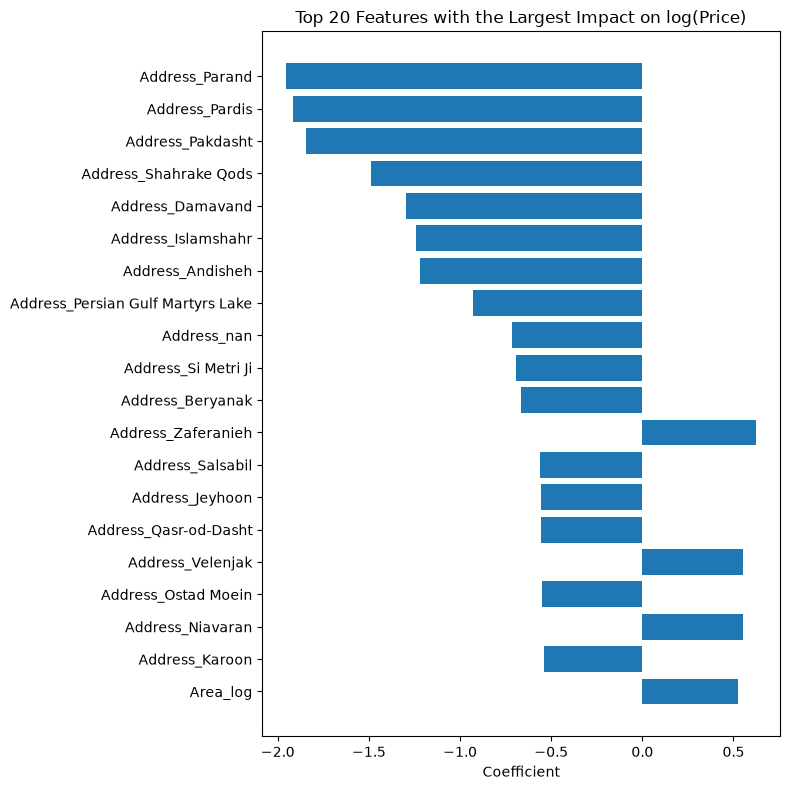

In [10]:
top20 = coef_df.head(20)
plt.figure(figsize=(8,8))
plt.barh(top20['feature'], top20['coefficient'])
plt.title('Top 20 Features with the Largest Impact on log(Price)')
plt.xlabel('Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Regression Coefficient Analysis

Most of the largest coefficients correspond to **Address** categories, highlighting that **location is the strongest factor influencing house prices**. Compared with the baseline location, areas such as **Parand**, **Pardis**, and **Pakdasht** have large negative coefficients, while premium neighborhoods like **Zaferanieh**, **Velenjak**, and **Niavaran** have positive coefficients, reflecting their higher property values.

The coefficient of **Area_log** is also positive and influential, but its impact is smaller than that of **Address**, suggesting that **location plays a more important role than property size** in this model.


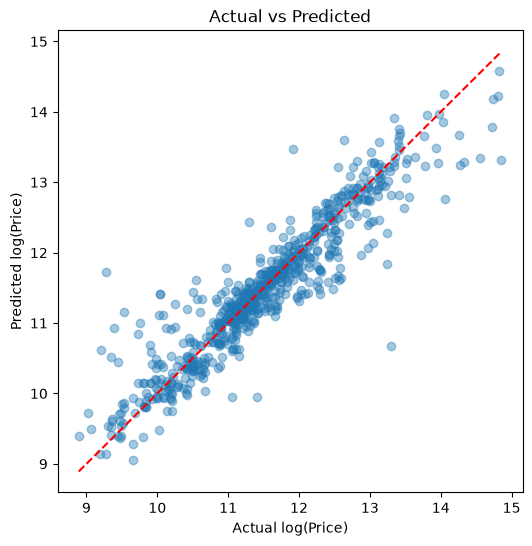

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual log(Price)')
plt.ylabel('Predicted log(Price)')
plt.title('Actual vs Predicted')
plt.show()

# Actual vs. Predicted

Most data points lie close to the **red diagonal line**, particularly within the **log(Price)** range of **10–13**, which represents the most common price range in the dataset. This indicates that the model performs well when predicting properties in the mid-price segment.

However, there is a slight deviation at both ends of the diagonal line. This does not significantly affect the overall performance and is likely due to the **regression toward the mean** behavior commonly observed in Linear Regression.



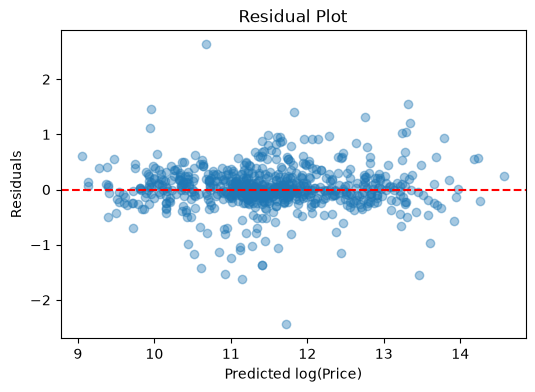

In [12]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel('Predicted log(Price)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()